In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimplifiedMambaBlock(nn.Module):
    def __init__(self, d_model=16, d_state=4):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        
        # 1. THE PHYSICS ENGINE (A Matrix - The Memory Leak)
        # Represents how fast the hidden state decays. 
        # In real Mamba, this is initialized carefully and kept negative.
        self.A_log = nn.Parameter(torch.log(torch.ones(d_model, d_state)))
        
        # 2. THE SELECTIVE MECHANISM (Input-Dependent Projections)
        # This is the breakthrough! B, C, and Delta change based on the word.
        self.proj_B = nn.Linear(d_model, d_state, bias=False)
        self.proj_C = nn.Linear(d_model, d_state, bias=False)
        self.proj_Delta = nn.Linear(d_model, d_model, bias=False)
        
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def print_header(self):
        print("="*90)
        print(f"{'MAMBA SELECTIVE SSM TENSOR JOURNEY (INFERENCE MODE)':^90}")
        print("="*90)
        print(f"Dimensions: d_model={self.d_model}, State_Size={self.d_state}")
        print("-" * 90)
        print(f"{'STEP':<10} | {'VARIABLE':<25} | {'CODE LOGIC':<25} | {'SHAPE':<15}")
        print("-" * 90)

    def print_step(self, step, var_name, logic, tensor):
        print(f"{step:<10} | {var_name:<25} | {logic:<25} | {str(list(tensor.shape)):<15}")

    def forward_recurrent(self, x_seq):
        """
        Simulates chatting with Mamba (Autoregressive Generation).
        We process one word at a time, updating a FIXED-SIZE hidden state.
        """
        B, T, D = x_seq.shape
        self.print_header()
        
        # The Mamba "KV Cache" equivalent is just a single fixed bucket.
        # Shape: (Batch, d_model, d_state). It NEVER grows over time T!
        hidden_state = torch.zeros(B, self.d_model, self.d_state, device=x_seq.device)
        self.print_step("0. Init", "Hidden State (Bucket)", "zeros(B, D, N)", hidden_state)
        print("." * 90)
        
        outputs = []
        A = -torch.exp(self.A_log) # Ensure decay is negative
        
        # We loop through time (like an RNN)
        for t in range(T):
            x_t = x_seq[:, t, :] # Get the single current word
            print(f"\n--- PROCESSING TOKEN {t+1} / {T} ---")
            self.print_step(f"{t+1}a", f"x_t (Token {t+1})", "Current Word", x_t)
            
            # 1. The Selective Mechanism (Brain calculates context)
            B_t = self.proj_B(x_t)     # (B, N)
            C_t = self.proj_C(x_t)     # (B, N)
            Delta_t = F.softplus(self.proj_Delta(x_t)) # (B, D) -> Must be positive
            
            self.print_step(f"{t+1}b", "Delta_t (Gatekeeper)", "proj_Delta(x_t)", Delta_t)
            
            # 2. Discretization (Turning physics into digital steps)
            # bar_A = exp(Delta * A)
            bar_A_t = torch.exp(Delta_t.unsqueeze(-1) * A) # (B, D, N)
            # bar_B = Delta * B
            bar_B_t = Delta_t.unsqueeze(-1) * B_t.unsqueeze(1) # (B, D, N)
            
            self.print_step(f"{t+1}c", "bar_A_t (Discrete Leak)", "exp(Delta * A)", bar_A_t)
            
            # 3. The State Update (The Magic Loophole)
            # Notice we OVERWRITE hidden_state. We do not concatenate!
            hidden_state = bar_A_t * hidden_state + bar_B_t * x_t.unsqueeze(-1)
            
            self.print_step(f"{t+1}d", "UPDATED Hidden State", "h = A*h + B*x", hidden_state)
            
            # 4. Output Projection
            # y = C * h
            y_t = (hidden_state * C_t.unsqueeze(1)).sum(dim=-1) # (B, D)
            outputs.append(y_t)
            self.print_step(f"{t+1}e", "y_t (Predicted Word)", "sum(h * C)", y_t)
            
        print("="*90)
        final_output = self.out_proj(torch.stack(outputs, dim=1))
        print(f"FINAL SEQUENCE OUTPUT SHAPE: {list(final_output.shape)}")
        print("Notice that 'Hidden State' shape never changed from [1, 16, 4]!")
        return final_output

if __name__ == "__main__":
    torch.manual_seed(123)
    dummy_input = torch.randn(1, 4, 16) # Batch=1, Tokens=4, Dim=16
    mamba = SimplifiedMambaBlock()
    mamba.forward_recurrent(dummy_input)

                   MAMBA SELECTIVE SSM TENSOR JOURNEY (INFERENCE MODE)                    
Dimensions: d_model=16, State_Size=4
------------------------------------------------------------------------------------------
STEP       | VARIABLE                  | CODE LOGIC                | SHAPE          
------------------------------------------------------------------------------------------
0. Init    | Hidden State (Bucket)     | zeros(B, D, N)            | [1, 16, 4]     
..........................................................................................

--- PROCESSING TOKEN 1 / 4 ---
1a         | x_t (Token 1)             | Current Word              | [1, 16]        
1b         | Delta_t (Gatekeeper)      | proj_Delta(x_t)           | [1, 16]        
1c         | bar_A_t (Discrete Leak)   | exp(Delta * A)            | [1, 16, 4]     
1d         | UPDATED Hidden State      | h = A*h + B*x             | [1, 16, 4]     
1e         | y_t (Predicted Word)      | sum(h * C)      

Calculating Mamba vs Transformer memory footprints...
✅ Plot saved successfully as 'mamba_memory_miracle.png'


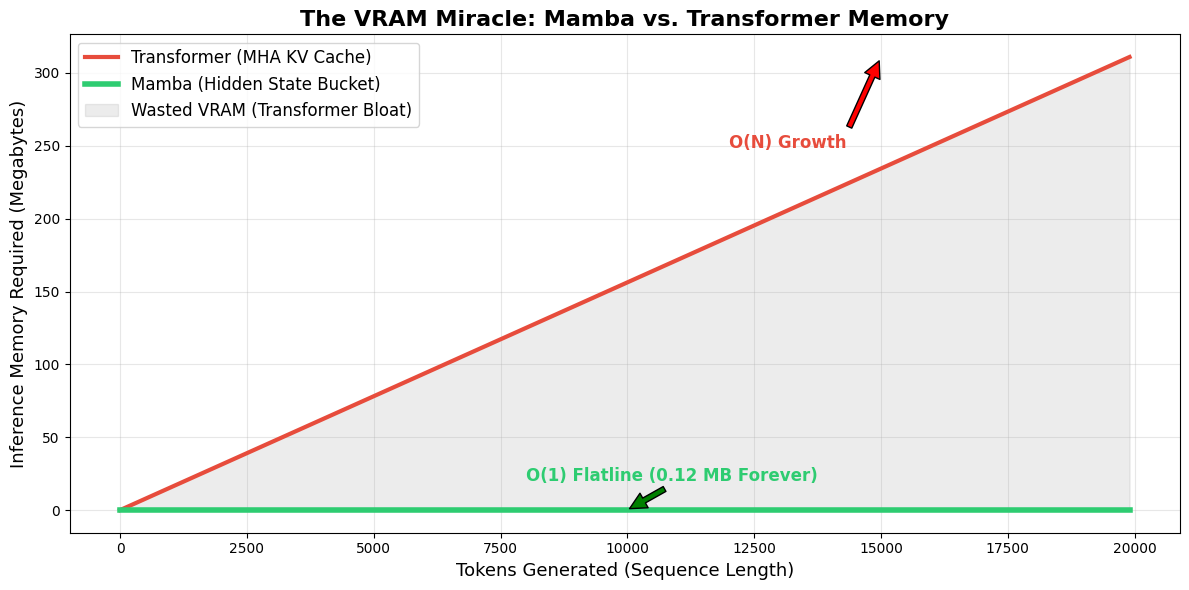

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mamba_vs_transformer():
    print("Calculating Mamba vs Transformer memory footprints...")
    
    seq_length = np.arange(1, 20000, 100) # Simulating up to 20,000 tokens
    
    # Model Specs (Roughly 7B parameter scale)
    d_model = 4096
    num_heads = 32
    head_dim = 128
    d_state = 16 # Mamba's typical state expansion size
    
    # 1. Transformer MHA Memory (Grows linearly over time O(N))
    # Stored = 2 (K&V) * T * num_heads * head_dim
    transformer_bytes = 2 * seq_length * num_heads * head_dim * 2 # 2 bytes for fp16
    transformer_mb = transformer_bytes / (1024 * 1024)
    
    # 2. Mamba Memory (Flat O(1))
    # Stored = d_model * d_state (Just the rolling bucket!)
    # Notice 'seq_length' is entirely absent from this formula.
    mamba_bytes = d_model * d_state * 2 # 2 bytes for fp16
    mamba_mb = np.full_like(seq_length, mamba_bytes / (1024 * 1024), dtype=float)

    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    plt.plot(seq_length, transformer_mb, label='Transformer (MHA KV Cache)', color='#e74c3c', linewidth=3)
    plt.plot(seq_length, mamba_mb, label='Mamba (Hidden State Bucket)', color='#2ecc71', linewidth=4)
    
    plt.fill_between(seq_length, mamba_mb, transformer_mb, color='gray', alpha=0.15, label='Wasted VRAM (Transformer Bloat)')
    
    plt.title("The VRAM Miracle: Mamba vs. Transformer Memory", fontsize=16, fontweight='bold')
    plt.xlabel("Tokens Generated (Sequence Length)", fontsize=13)
    plt.ylabel("Inference Memory Required (Megabytes)", fontsize=13)
    
    # Annotations to highlight the math
    plt.annotate(f'O(N) Growth', xy=(15000, transformer_mb[-1]), xytext=(12000, transformer_mb[-1]*0.8), 
                 arrowprops=dict(facecolor='red', shrink=0.05), color='#e74c3c', fontsize=12, fontweight='bold')
    
    plt.annotate(f'O(1) Flatline ({mamba_mb[0]:.2f} MB Forever)', xy=(10000, mamba_mb[0]), xytext=(8000, 20), 
                 arrowprops=dict(facecolor='green', shrink=0.05), color='#2ecc71', fontsize=12, fontweight='bold')

    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()

if __name__ == "__main__":
    plot_mamba_vs_transformer()